# 模型評估指標 (Model Evaluation)

學習目標：
- 了解混淆矩陣是什麼
- 學會 Precision、Recall、F1-score
- 知道什麼情況用哪個指標
- 畫出 ROC 曲線

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_curve, auc)

## 1. 混淆矩陣 (Confusion Matrix)

預測結果只有四種可能：
- TP（True Positive）：預測是，實際也是 ✅
- TN（True Negative）：預測否，實際也否 ✅
- FP（False Positive）：預測是，實際否 ❌（誤報）
- FN（False Negative）：預測否，實際是 ❌（漏報）

In [3]:
# 建立模擬資料（運動員是否獲獎）
X, y = make_classification(n_samples=1000, n_features=10,
                           weights=[0.7, 0.3], random_state=42)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# 訓練模型
model = LogisticRegression(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# 混淆矩陣
cm = confusion_matrix(y_test, y_pred)
print('混淆矩陣：')
print(cm)
print(f'\nTN={cm[0,0]}  FP={cm[0,1]}')
print(f'FN={cm[1,0]}  TP={cm[1,1]}')

混淆矩陣：
[[117  13]
 [ 16  54]]

TN=117  FP=13
FN=16  TP=54


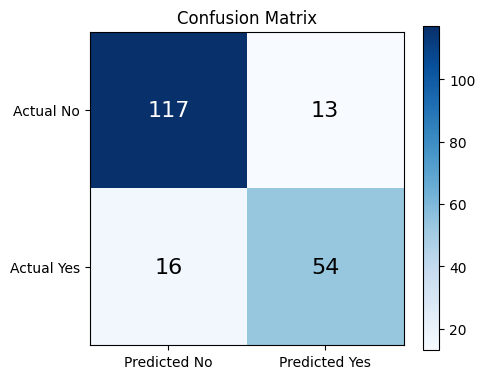

In [4]:
# 視覺化混淆矩陣
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap='Blues')
plt.colorbar(im)
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Predicted No', 'Predicted Yes'])
ax.set_yticklabels(['Actual No', 'Actual Yes'])
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha='center', va='center',
                fontsize=16, color='white' if cm[i,j] > cm.max()/2 else 'black')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

## 2. 三個關鍵指標

- Precision（精確率）= TP / (TP + FP)
  → 我說「獲獎」的人裡面，有多少真的獲獎？

- Recall（召回率）= TP / (TP + FN)
  → 所有真正獲獎的人裡面，我找到了幾個？

- F1-score = 兩者的調和平均
  → 當兩者都重要時使用

運動科學應用：
預測運動員是否受傷時，Recall 更重要
（寧可誤報，不能漏掉真正要受傷的人）

In [5]:
# 完整分類報告
print(classification_report(y_test, y_pred,
      target_names=['未獲獎', '獲獎']))

              precision    recall  f1-score   support

         未獲獎       0.88      0.90      0.89       130
          獲獎       0.81      0.77      0.79        70

    accuracy                           0.85       200
   macro avg       0.84      0.84      0.84       200
weighted avg       0.85      0.85      0.85       200



## 3. ROC 曲線

ROC 曲線顯示「不同閾值下」模型的表現。
AUC（曲線下面積）越接近 1 越好，0.5 代表跟亂猜一樣。

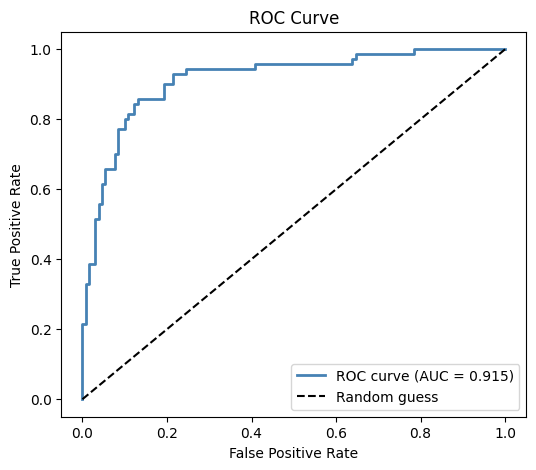

AUC = 0.915


In [6]:
# 取得預測機率（不是 0/1，而是 0~1 的機率值）
y_prob = model.predict_proba(X_test)[:, 1]

# 計算 ROC 曲線
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# 畫圖
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='steelblue', linewidth=2,
         label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

print(f'AUC = {roc_auc:.3f}')

## 4. 我的學習筆記

1. 這個主題在做什麼：
   用混淆矩陣、Precision、Recall、F1、ROC/AUC
   評估分類模型的好壞。光看 accuracy 不夠，
   因為不平衡資料（如99%沒得獎）會讓accuracy虛高。

2. 什麼時候用哪個指標：
   - 不能漏報 → 重視 Recall（例：受傷預測）
   - 不能誤報 → 重視 Precision（例：藥物篩選）
   - 兩者都重要 → F1-score
   - 整體模型比較 → AUC

3. 我覺得最難理解的地方：
   （填入你自己的想法）

4. 這個跟我研究的連結：
   預測運動員表現或受傷風險時，
   選對評估指標跟建模型一樣重要。